# Packages

In [3]:
%matplotlib widget

In [4]:
try:
    import cupy as xp
except ImportError:
    import numpy as xp

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from cupyx.scipy.ndimage import shift as shiftcp

In [6]:
from libertem_holo.base.io import Results, InputData
from libertem_holo.base.reconstr import reconstruct_frame, reconstruct_bf, phase_offset_correction
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import ImageCorrelator
from libertem_holo.base.filters import clipped
from libertem_holo.base.unwrap import phase_unwrap

c:\Users\mkhelfallah\miniforge3\envs\HOLO_automation\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\mkhelfallah\miniforge3\envs\HOLO_automation\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\mkhelfallah\miniforge3\envs\HOLO_automation\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


# Load hologram stacks

Data is loaded from dm3 or dm4 files directly into a 'data' object which contains the stack as well as metadata information such as the pixel size in meters, the total exposure time in seconds and the GMS tags.

In [7]:
# Reference stack
#path = "../../../donnees/U3_10_ref_116V_19k_stack.dm4"
path = r"C:\Users\mkhelfallah\Documents\donnees\holography\datasets\stack_ref_minus.dm4"
data_ref = InputData.load_from_dm(path)

# Object stack
#path = "../../../donnees/U3_11_116V_19k_stack.dm4"
path = r"C:\Users\mkhelfallah\Documents\donnees\holography\datasets\stack_obj_minus.dm4"
data_obj = InputData.load_from_dm(path)

In [8]:
data_obj.pixelsize, data_obj.exposure_time, data_obj.shape

(1.4522670209407806e-10, np.float64(60.0), (30, 3838, 3710))

Text(0, 0.5, 'nm')

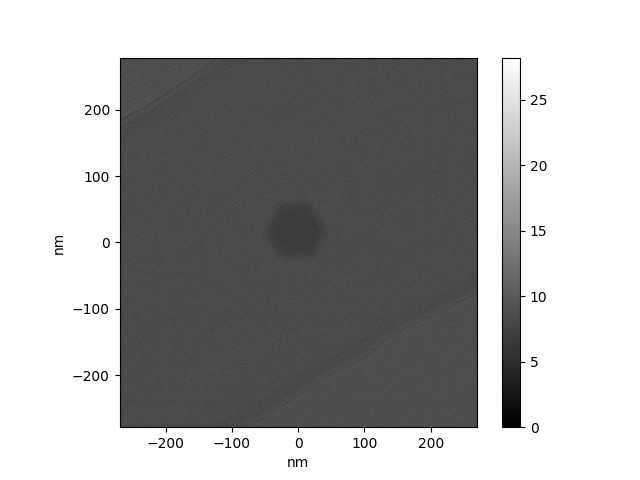

In [9]:
# Show one frame of the stack

frame = data_obj.data[0]
extent=(
    -data_obj.pixelsize*frame.shape[1]/2*1e9, data_obj.pixelsize*frame.shape[1]/2*1e9,
    -data_obj.pixelsize*frame.shape[0]/2*1e9, data_obj.pixelsize*frame.shape[0]/2*1e9,
)
plt.figure()
im = plt.imshow(
    frame, vmin=np.min(clipped(frame)), vmax=np.max(clipped(frame)),
    extent=extent, cmap='gray',
)
plt.colorbar()
plt.xlabel('nm')
plt.ylabel('nm')

# Hologram reconstruction parameters

The hologram reconstruction parameters are:

    - sideband position
    
    - sideband size
    
    - output shape
    
    - line filter for Fresnel fringes (length and width)
    
    - Butterworth filter order
    
The parameters are stored in the 'HoloParams' object. A convenient function 'from_hologram' calculates all parameters automatically with default values, but every parameter is editable. 

In [55]:
# One frame is passed as argument for the parameters determination, for example the first frame of the reference stack.

holoparams = HoloParams.from_hologram(data_ref.data[0], xp=xp, line_filter_width=0.00001)

In [56]:
holoparams.sb_size, holoparams.sb_position, holoparams.out_shape

(121.94465957966344, (3639.0, 3569.0), (959, 927))

In [12]:
# if necessary, we can force a sideband size, or output shape in the holoparams
# if the output shape does not respect the aspect ratio of the original hologram, 
# a warning is raised to warn the user that the pixel size will no longer be valid for 
# both x and y dimensions, continue at your own risk

holoparams = HoloParams.from_hologram(data_ref.data[0], xp=xp, sb_size=200, out_shape=(512, 512))

C:\Users\mkhelfallah\Documents\source\libertem-holo\src\libertem_holo\base\utils.py:308: UserWarning: out_shape should have the same aspect ratio as the hologram shape to preserve the correct pixel size in both dimensions.
  warnings.warn(


In [ ]:
holoparams.sb_size, holoparams.sb_position, holoparams.out_shape

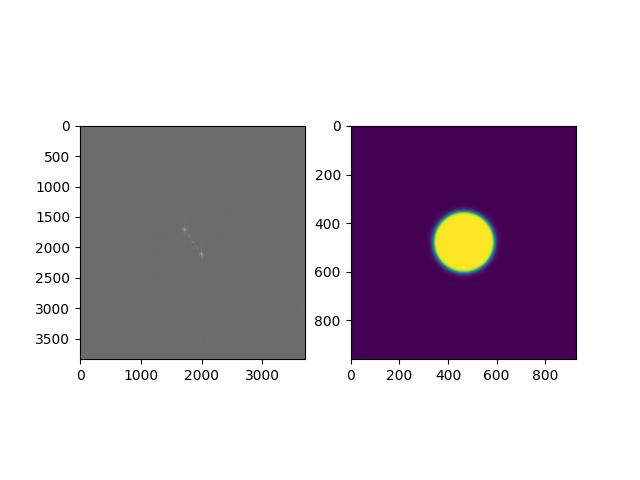

In [57]:
# we can visualise the aperture created to filter the FFT

fig, ax = plt.subplots(ncols=2)#, sharex=True, sharey=True)
aperture = xp.fft.fftshift(holoparams.aperture).get()
fft = xp.fft.fftshift(xp.fft.fft2(xp.asarray(data_obj.data[0]))).get()
#fft = xp.roll(fft, np.array(holoparams.sb_position_int).astype(np.int64), axis=(0, 1)).get()
#fft = fft[holoparams.slice_fft]

ax[0].imshow(np.log1p(np.abs(fft)), cmap='gray')
ax[1].imshow(aperture)

# Reconstruction of one frame

In [58]:
# before reconstructing the whole stack, it can be useful to check the reconstruction parameters
# by reconstructing one single frame and plotting the amplitude and phase of the complex wave.

# First the object wave is reconstructed
wave_obj = reconstruct_frame(
    data_obj.data[0], sb_pos=holoparams.sb_position, aperture=holoparams.aperture,
    slice_fft=holoparams.slice_fft, xp=xp
)

# Then the reference wave...
wave_ref = reconstruct_frame(
    data_ref.data[0], sb_pos=holoparams.sb_position, aperture=holoparams.aperture,
    slice_fft=holoparams.slice_fft, xp=xp
)

# ... and the reference wave is removed from the object wave to reduce distorsions
wave = wave_obj / wave_ref

If you are using a GPU and the cupy library instead of numpy, the final wave must be transferred to CPU before plotting

In [59]:
wave = wave.get()

The amplitude and phase images can then be extracted and plotted

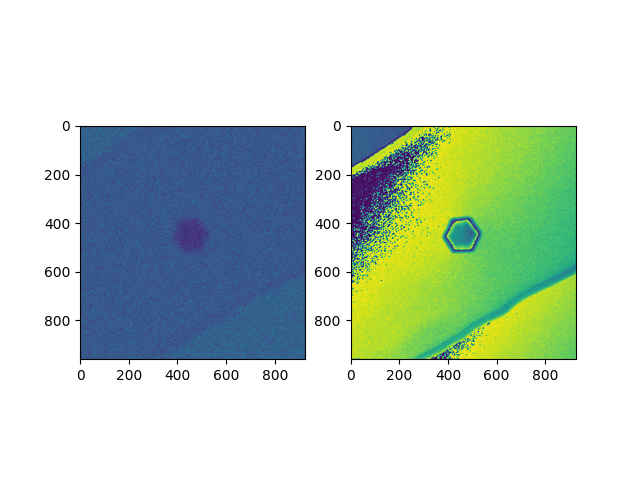

In [60]:
amp = np.abs(wave)
phase = np.angle(wave)

fig, ax = plt.subplots(ncols=2)
ax[0].imshow(amp, vmin=np.min(clipped(amp)), vmax=np.max(clipped(amp)))
ax[1].imshow(phase)

The bright field (centerband filtering) of the hologram can also be reconstructed. The same 'holoparams' can be used as well.

In [61]:
bf = reconstruct_bf(data_obj.data[0], aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)

In [62]:
# if using cupy
bf = bf.get()

C:\Users\mkhelfallah\AppData\Local\Temp\ipykernel_36392\3991511668.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


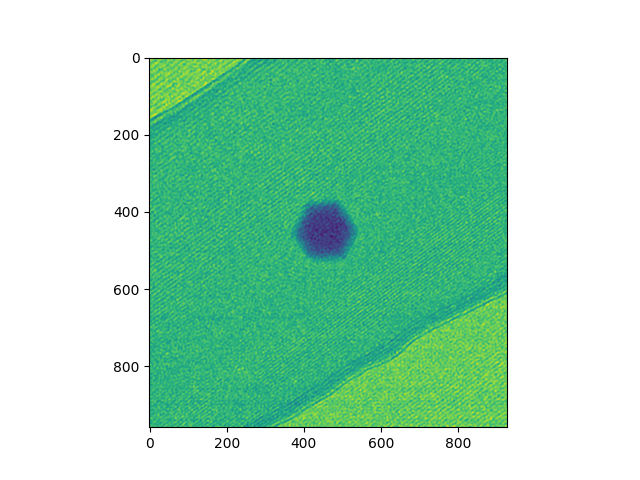

In [63]:
plt.figure()
plt.imshow(bf)

# Reconstruction stack

Now that we are satisfied with our reconstruction parameters, we can reconstruct a stack.

temporary function, needs to import it from convenience ? or reconstr module

In [84]:
def reconstruct_stack(stack, stack_ref=None, holoparams=None, xp=xp):
    sig_shape = stack.data[0].shape
    out_shape = (sig_shape[0]//4, sig_shape[1]//4)
    if holoparams is None:
        holoparams = HoloParams.from_hologram(
            stack.data[0], out_shape=out_shape, xp=xp,
            line_filter_width=0.001, line_filter_length=0.0009, central_band_mask_radius=100,
        )
    px_size = stack.pixelsize * holoparams.scale_factor
    correlator = ImageCorrelator(hanning=True, normalization='phase', binning=2, upsample_factor=10, xp=xp)
    waves_aligned = []
    bfs_aligned = []
    for i in tqdm.tqdm(range(len(stack.data))):
        obj = stack.data[i]

        wave_obj = reconstruct_frame(
            frame=obj, sb_pos=holoparams.sb_position,
            aperture=holoparams.aperture, slice_fft=holoparams.slice_fft,
            xp=xp,
        )
        if i == 0:
            bf_obj_0 = reconstruct_bf(frame=obj, aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)
            f1 = correlator.prepare_input(bf_obj_0)

        bf_obj = reconstruct_bf(frame=obj, aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)
        f2 = correlator.prepare_input(bf_obj)

        corr_res = correlator.correlate(ref_image=f1, moving_image=f2)
        shifts = corr_res.shift

        if wave_obj.device == 'cpu':
            shifts = tuple(float(x) for x in corr_res.shift)
            wave_shifted = shift(wave_obj, shifts)
            bf_shifted = shift(bf_obj, shifts)
        else:
            wave_shifted = shiftcp(wave_obj, shifts)
            bf_shifted = shiftcp(bf_obj, shifts)

        waves_aligned.append(wave_shifted)
        bfs_aligned.append(bf_shifted)

    waves_aligned = np.stack(waves_aligned)
    bfs_aligned = np.stack(bfs_aligned)

    wave_avg, _, _ = phase_offset_correction(waves_aligned.get())
    bf_avg, _, _ = phase_offset_correction(bfs_aligned.get())


    if stack_ref is None:
        wave_ref = np.ones_like(wave_avg)
    else:
        if holoparams is None:
            holoparams = HoloParams.from_hologram(
                stack_ref.data[0], out_shape=out_shape, xp=cp, line_filter_width=5, line_filter_length=0.9, central_band_mask_radius=100,
            )
        waves_ref = []

        for i in tqdm.tqdm(range(len(stack_ref.data))):
            ref = stack_ref.data[i]
            wave_ref = reconstruct_frame(
                frame=ref, sb_pos=holoparams.sb_position, 
                aperture=holoparams.aperture, slice_fft=holoparams.slice_fft,
                xp=xp,
            )
            waves_ref.append(wave_ref)

        waves_ref = np.stack(waves_ref)
        wave_ref, _, _ = phase_offset_correction(waves_ref.get())

    wave = wave_avg / wave_ref
    return wave, bf_avg, px_size

In [71]:
from scipy.ndimage import shift
import time
from ncempy.io.dm import fileDM

In [ ]:
def reconstruct_stack_old(path, filename, fileref=None, cp=xp):
    t0 = time.time()
    with fileDM(path+filename) as f:
        stack = f.getDataset(0)['data']
        scale = f.getMetadata(0)['Calibrations Dimension 1 Scale']
        date =  f.getMetadata(0)['DataBar Acquisition Date']
        exposure = f.getMetadata(0)['DataBar Exposure Time (s)']
    t1 = time.time()
    print(f"Load file done (t={t1-t0} s)")
    stack = stack[:10]
    if len(stack.shape)==2:
        stack = stack.reshape((1,)+ stack.shape)
    sig_shape = stack[0].shape
    out_shape = (sig_shape[0]//4, sig_shape[1]//4)
    holoparams = HoloParams.from_hologram(
        stack[0], out_shape=out_shape, xp=cp, line_filter_width=2, line_filter_length=0.9,
        central_band_mask_radius=100,
    )
    
    px_size = scale * 4
    
    correlator = ImageCorrelator(hanning=True, normalization='phase', binning=2, upsample_factor=10, xp=cp)
    waves_aligned = []
    bfs_aligned = []
    for i in tqdm.tqdm(range(len(stack))):
        obj = stack[i]
        
        wave_obj = reconstruct_frame(
            frame=obj, sb_pos=holoparams.sb_position, 
            aperture=holoparams.aperture, slice_fft=holoparams.slice_fft,
            xp=cp,
        )
        if i == 0:
            bf_obj_0 = reconstruct_bf(frame=obj, aperture=holoparams.aperture.get(), slice_fft=holoparams.slice_fft)
            f1 = correlator.prepare_input(np.abs(bf_obj_0))
        bf_obj = reconstruct_bf(frame=obj, aperture=holoparams.aperture.get(), slice_fft=holoparams.slice_fft)
        f2 = correlator.prepare_input(np.abs(bf_obj))
        corr_res = correlator.correlate(ref_image=f1, moving_image=f2)
        #shifts = tuple(float(x) for x in corr_res.shift)
        shifts = corr_res.shift
        wave_shifted = shiftcp(wave_obj, shifts)
        waves_aligned.append(wave_shifted)
        bf_shifted = shift(bf_obj, tuple(float(x) for x in corr_res.shift))
        bfs_aligned.append(bf_shifted)
    waves_aligned = np.stack(waves_aligned)
    bfs_aligned = np.stack(bfs_aligned)
    
    wave_avg, _, _ = phase_offset_correction(waves_aligned.get())
    wave_bf, _, _ = phase_offset_correction(bfs_aligned)


    if fileref == None:
        wave_ref = np.ones_like(wave_avg)
    else:
        with fileDM(path+fileref) as f:
            stack_ref = f.getDataset(0)['data']
        stack_ref = stack_ref[:10]
        holoparams = HoloParams.from_hologram(
            stack_ref[0], out_shape=out_shape, xp=cp, line_filter_width=5, line_filter_length=0.9, central_band_mask_radius=100,
        )
        
        waves_ref = []

        for i in tqdm.tqdm(range(len(stack_ref))):
            ref = stack_ref[i]
            wave_ref = reconstruct_frame(
                frame=ref, sb_pos=holoparams.sb_position, 
                aperture=holoparams.aperture, slice_fft=holoparams.slice_fft,
                xp=cp,
            )
            waves_ref.append(wave_ref)
        waves_ref = np.stack(waves_ref)
        wave_ref, _, _ = phase_offset_correction(waves_ref.get())

    wave = wave_avg / wave_ref
    
    data = {
        'wave': wave, 'px_size': px_size, 'filename': filename[:-4],
        'ampbf': np.abs(wave_bf), 'date': date, 'exposure': exposure * len(stack),
    }
    
    return data

In [66]:
data_obj.shape

(30, 3838, 3710)

In [85]:
wave, bf, pxsize = reconstruct_stack(stack=data_obj, stack_ref=data_ref, holoparams=None)

C:\Users\mkhelfallah\Documents\source\libertem-holo\src\libertem_holo\base\utils.py:308: UserWarning: out_shape should have the same aspect ratio as the hologram shape to preserve the correct pixel size in both dimensions.
  warnings.warn(
100%|██████████| 30/30 [02:04<00:00,  4.14s/it]


ArpackNoConvergence: ARPACK error -1: No convergence (301 iterations, 0/1 eigenvectors converged) [ARPACK error -14: ZNAUPD did not find any eigenvalues to sufficient accuracy.]

In [ ]:
#wave, bf, pxsize = reconstruct_stack(stack=data_obj, stack_ref=data_ref, holoparams=None, xp=np)
data = reconstruct_stack_old(
    path=r"C:\Users\mkhelfallah\Documents\donnees\holography\datasets",
    filename=r"\stack_obj_minus.dm4",
    fileref=r"\stack_ref_minus.dm4",
    cp=xp,
)

Load file done (t=9.047185897827148 s)


C:\Users\mkhelfallah\Documents\source\libertem-holo\src\libertem_holo\base\utils.py:308: UserWarning: out_shape should have the same aspect ratio as the hologram shape to preserve the correct pixel size in both dimensions.
  warnings.warn(
100%|██████████| 10/10 [00:02<00:00,  4.14it/s]


In [82]:
data['wave'].shape

(959, 927)

In [48]:
waves_aligned.shape

(30, 959, 927)

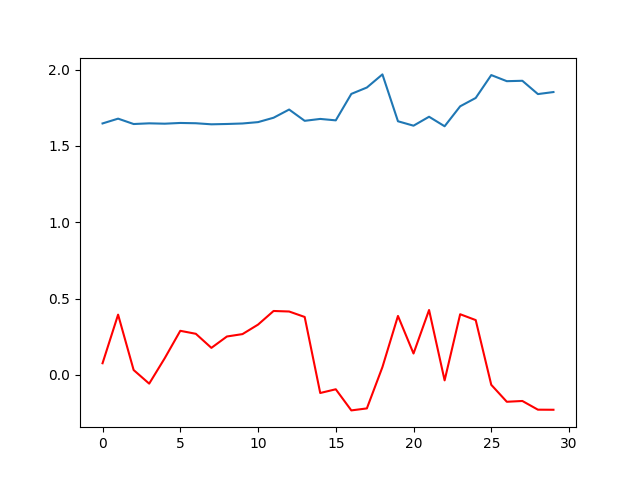

In [54]:
plt.figure()
plt.plot(np.std(np.angle(waves_aligned.get()), axis=(1,2)))
plt.plot(np.mean(np.angle(waves_aligned.get()), axis=(1,2)), c='r')

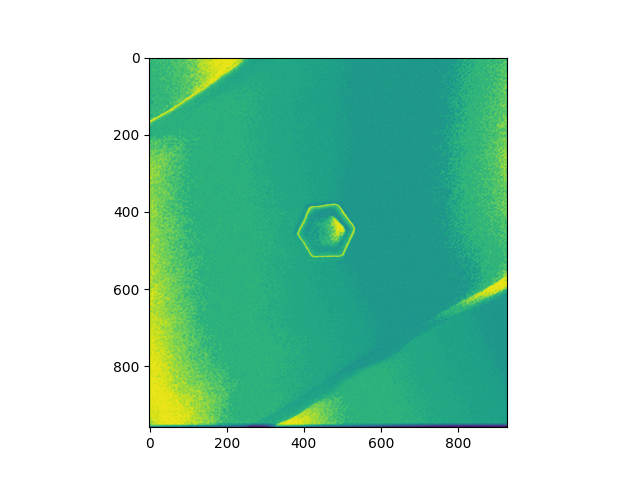

In [49]:
plt.figure()
plt.imshow(np.std(np.angle(waves_aligned.get()), axis=0))

In [50]:
wave_avg, a, b = phase_offset_correction(waves_aligned.get())

ArpackNoConvergence: ARPACK error -1: No convergence (301 iterations, 0/1 eigenvectors converged) [ARPACK error -14: ZNAUPD did not find any eigenvalues to sufficient accuracy.]

In [ ]:
phase = phase_unwrap(np.angle(wave))

In [27]:
res = Results(complex_wave=wave, unwrapped_phase=phase, brightfield=bf)

`res` contains `complex_wave`, `unwrapped_phase`  and `brightfield`. Metadata can also be added.

In [33]:
res.metadata = {'temperature': 300, 'T unit': 'K'}

In [34]:
res.metadata

{'temperature': 300, 'T unit': 'K'}

or add metadata from input

In [37]:
res.metadata_from_input(input_data=data_obj)

In [38]:
res.metadata


{'temperature': 300,
 'T unit': 'K',
 'stack_shape': [10, 3836, 3708],
 'exposure_time': 50.0,
 'acquisition_timestamp': '2025-03-01T18:36:53.523785+00:00'}

 and save

In [41]:
res.save("test.npz")